# Función Logística (Regresión Logística)

Algoritmo de clasificación binaria que modela la **probabilidad** de que una muestra pertenezca a una clase.

## Función Sigmoide

Transforma cualquier valor real en un número entre 0 y 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

donde  $z = \theta^T x$ es la combinación lineal de los parámetros y las features.

## Predicción

$$\hat{y} = \sigma(\theta^T x) = P(y=1 \mid x)$$

Si $\hat{y} \geq 0.5$ → clase 1; si $\hat{y} < 0.5$ → clase 0.

## Función de Pérdida (Binary Cross-Entropy)

Mide qué tan mal predice el modelo:

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

## Descenso del Gradiente

Actualiza $\theta$ iterativamente para minimizar:

$$\theta := \theta - \alpha \cdot \frac{\partial J}{\partial \theta} = \theta - \frac{\alpha}{m} X^T (\hat{y} - y)$$

donde $\alpha$ es la tasa de aprendizaje (*learning rate*).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

perdidatotal=[]

#Definir la función sigmoide
def sigmoid(x):
  return 1/(1+np.exp(-x))


#Función de entrenamiento de la regresión logística
def logistic_regression(X,y,lr,epochs): #epochs -> El número de veces que entreno el modelo.

  m,n=X.shape
  theta=np.zeros(n)

  #Descenso del gradiente
  for epoch in range(epochs):
    #Calcular la probabilidad (predicción) y la perdida.
    z=np.dot(X,theta)
    h=sigmoid(z)
    loss=-np.mean(y*np.log(h)+(1-y)*np.log(1-h)) #Cálculo de la función de perdida.
    perdidatotal.append(loss)

    #Calcular el gradiente.
    gradient=np.dot(X.T,(h-y))/m

    #Actualizar parametros
    theta-=lr*gradient

    #Imprimir la perdidad de cada época
    if(epoch+1)%100==0:
      print(f"Epoca {epoch+1}/{epochs}, Perdida (Loss):{loss}")

  return theta


In [2]:
#Datos de ejemplo:
X = np.array([[1, 2], [1, 3], [1, 4], [1, 5]])
y = np.array([0, 0, 1, 1])

#Entrenar el modelo.
learning_rate=0.1
num_epochs=100000
optimal_params=logistic_regression(X,y,learning_rate,num_epochs)

Epoca 100/100000, Perdida (Loss):0.5297226475311346
Epoca 200/100000, Perdida (Loss):0.4411731344833296
Epoca 300/100000, Perdida (Loss):0.37969678169767873
Epoca 400/100000, Perdida (Loss):0.3351683765663329
Epoca 500/100000, Perdida (Loss):0.30160014920920913
Epoca 600/100000, Perdida (Loss):0.27540291236941555
Epoca 700/100000, Perdida (Loss):0.2543551007877653
Epoca 800/100000, Perdida (Loss):0.23703032782480188
Epoca 900/100000, Perdida (Loss):0.22247951428947998
Epoca 1000/100000, Perdida (Loss):0.2100501685444313
Epoca 1100/100000, Perdida (Loss):0.1992803692467041
Epoca 1200/100000, Perdida (Loss):0.18983450026162715
Epoca 1300/100000, Perdida (Loss):0.181463045584487
Epoca 1400/100000, Perdida (Loss):0.1739766868140021
Epoca 1500/100000, Perdida (Loss):0.16722916020773293
Epoca 1600/100000, Perdida (Loss):0.16110563009152792
Epoca 1700/100000, Perdida (Loss):0.1555146266107723
Epoca 1800/100000, Perdida (Loss):0.15038234144434226
Epoca 1900/100000, Perdida (Loss):0.14564851738

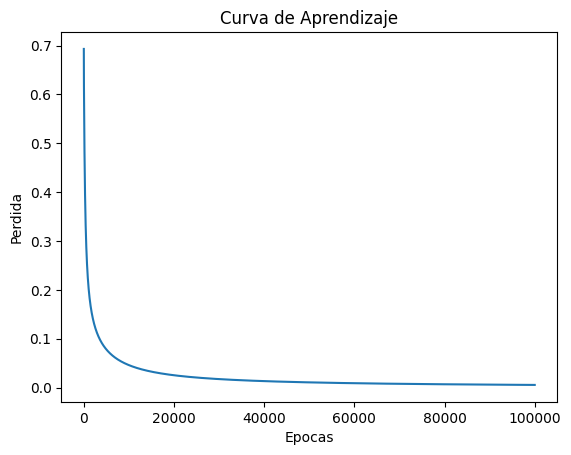

Parametros óptimos: [-31.69173182   9.09315118]


In [3]:
#Plotear la curva de aprendizaje.
plt.plot(range(1, num_epochs+1), perdidatotal)
plt.xlabel("Epocas")
plt.ylabel("Perdida")
plt.title("Curva de Aprendizaje")
plt.show()
print("Parametros óptimos:",optimal_params)

# Lo mismo pero implementando la libreria scikit-learn

In [4]:
from sklearn.linear_model import LogisticRegression

#Datos de ejemplo:
X = np.array([[1, 2], [1, 3], [1, 4], [1, 5]])
y = np.array([0, 0, 1, 1])

#Entrenar el modelo
modelo=LogisticRegression()
modelo.fit(X,y)

#Parametros encontrados
print("Parametros óptimos conseguidos:", modelo.intercept_, modelo.coef_)

Parametros óptimos conseguidos: [-3.35333948] [[1.15620192e-04 9.58114714e-01]]


1. 'liblinear'  ->  Edison
2. 'lbfgs'      -> Yerly
3. 'newton-cg'  -> Santiago Criollo
4. 'newton-cholesky' -> Daniel
5. 'sag'   ->Jose Luis
6. 'saga'  -> Juan Pablo
7. Talero queda pendiente para otro tema. Expo. Pendiente.

Martes 16 de Abril. Exposición en Detalle para 15 minutos.